<a href="https://colab.research.google.com/github/fbildirici/MLPy/blob/main/deeplearninghomework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### We need to install libraries. Basically we will use Tensor and Scikit.



In [30]:
!pip install -q tensorflow pandas numpy matplotlib scikit-learn openpyxl
print("Libraries installed successfully we will use mainly scikitlearn and tensor.")


Kütüphaneler başarıyla yüklendi kullanabilirsiniz.


TurkeyBus.xlsx dataset installing into working environment for detailed analysis.
---



In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Excel'den oku
df = pd.read_excel("turkeybus.xlsx")
df.columns = ["YearWeek", "Passengers"]

# Tarihi düzenle
df["Date"] = pd.to_datetime(df["YearWeek"].str.replace('-', '-W') + '-1', format="%Y-W%W-%w")
df = df.set_index("Date")[["Passengers"]]

# Ön izleme
print("📅 İlk 5 veri:")
print(df.head())
print(f"\n🔢 Toplam gözlem sayısı: {len(df)}")
print(f"⏳ Veri aralığı: {df.index.min().date()} → {df.index.max().date()}")


📅 İlk 5 veri:
            Passengers
Date                  
1950-01-02    1.700000
1950-01-09    1.702311
1950-01-16    1.704623
1950-01-23    1.706937
1950-01-30    1.709253

🔢 Toplam gözlem sayısı: 3952
⏳ Veri aralığı: 1950-01-02 → 2025-12-29


Eğitim ve Test Verisi Ayrımı (Önemli bir aşama ML açısından)

In [32]:
train = df.loc[:'2010']
test = df.loc['2010':]

print(f"🎓 Eğitim veri boyutu: {train.shape}")
print(f"🧪 Test veri boyutu: {test.shape}")


🎓 Eğitim veri boyutu: (3172, 1)
🧪 Test veri boyutu: (832, 1)


Min - Max Scaling and Normalization

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

print("✅ Eğitim verisi ölçeklendi.")
print("🎯 Ölçeklenmiş ilk 5 değer:")
print(train_scaled[:5])


✅ Eğitim verisi ölçeklendi.
🎯 Ölçeklenmiş ilk 5 değer:
[[0.00000000e+00]
 [9.58258680e-05]
 [1.91712911e-04]
 [2.87661130e-04]
 [3.83670525e-04]]


In [35]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

# RNN için 3D yapı (örnek sayısı, zaman adımı, özellik sayısı)
X_train = X_train.reshape((X_train.shape[0], SEQ_LEN, 1))
X_test = X_test.reshape((X_test.shape[0], SEQ_LEN, 1))

print(f"🧩 X_train şekli: {X_train.shape}")
print(f"🎯 y_train şekli: {y_train.shape}")


🧩 X_train şekli: (3160, 12, 1)
🎯 y_train şekli: (3160, 1)


**RNN Model And Preparation**

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# RNN Modeli
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(SEQ_LEN, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mae')
rnn_model.summary()

# Eğitimi başlat
history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.1100 - val_loss: 0.1002
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0261 - val_loss: 0.0679
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0204 - val_loss: 0.0449
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0187 - val_loss: 0.0452
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0152 - val_loss: 0.0365
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0142 - val_loss: 0.0480
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0138 - val_loss: 0.0336
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0128 - val_loss: 0.0344
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0120 - val_loss: 0.0408
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0139 - val_loss: 0.0319
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0121 - val_loss: 0.0336
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0122 - va

**An Analysis of Forecast and Performance**

In [37]:
# Tahminleri al
rnn_preds = rnn_model.predict(X_test)

# Geri ölçekle
rnn_preds_inv = scaler.inverse_transform(rnn_preds)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# MAE hesapla
from sklearn.metrics import mean_absolute_error
mae_rnn = mean_absolute_error(y_test_inv, rnn_preds_inv)
print(f"📏 RNN MAE (Mean Absolute Error): {mae_rnn:.3f} milyon yolcu")


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
📏 RNN MAE (Mean Absolute Error): 0.542 milyon yolcu


**Visualization Stage**

<ipython-input-38-5b73592415e6>:9: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


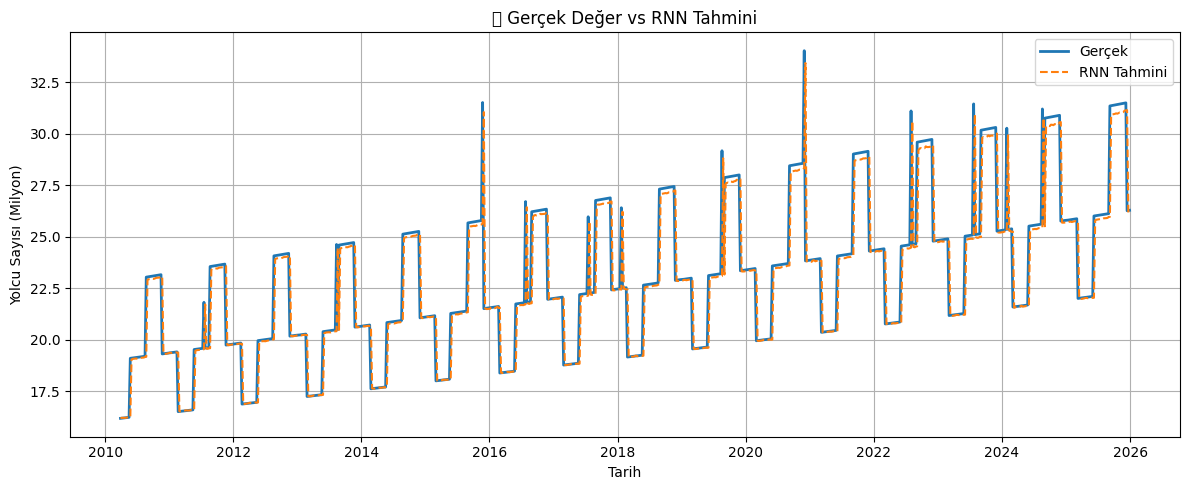

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Gerçek', linewidth=2)
plt.plot(df.index[-len(rnn_preds_inv):], rnn_preds_inv, label='RNN Tahmini', linestyle='--')
plt.title("📉 Gerçek Değer vs RNN Tahmini")
plt.xlabel("Tarih")
plt.ylabel("Yolcu Sayısı (Milyon)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Let's prepare to the simplest regression, others may give close results but it would be a better comparison, let's try Linear Regression.

In [39]:
from sklearn.linear_model import LinearRegression

# Lineer regresyon modeli
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(X_train.shape[0], SEQ_LEN), y_train)

# Tahmin yap
lr_preds = lr_model.predict(X_test.reshape(X_test.shape[0], SEQ_LEN))

# Geri ölçekleme
lr_preds_inv = scaler.inverse_transform(lr_preds.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))  # Zaten elimizde vardı, tekrar kullanıyoruz

# MAE hesapla
mae_lr = mean_absolute_error(y_test_inv, lr_preds_inv)
print(f"📏 Lineer Regresyon MAE: {mae_lr:.3f} milyon yolcu")


📏 Lineer Regresyon MAE: 0.588 milyon yolcu


<ipython-input-40-a2e0137d8dca>:9: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


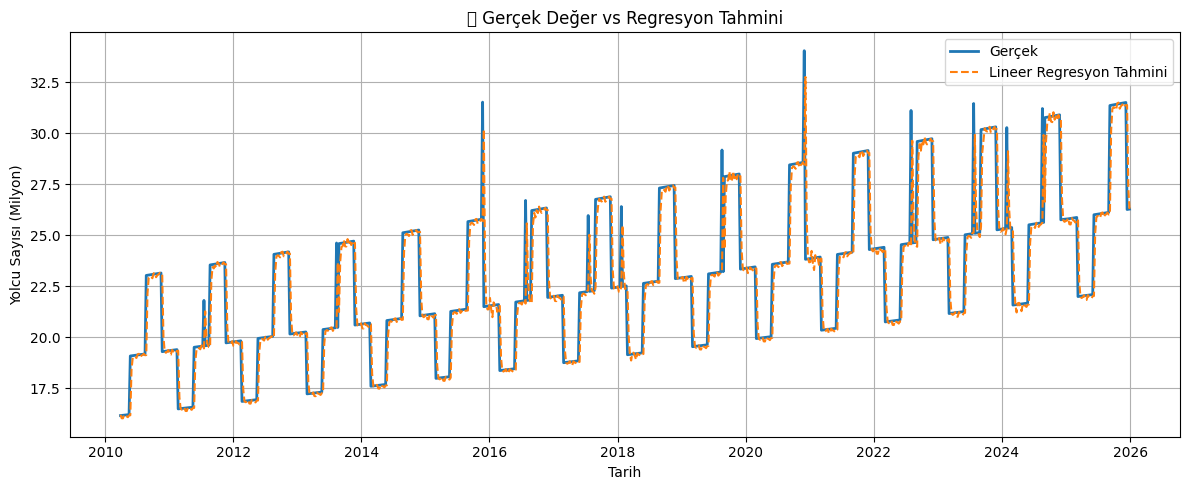

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Gerçek', linewidth=2)
plt.plot(df.index[-len(lr_preds_inv):], lr_preds_inv, label='Lineer Regresyon Tahmini', linestyle='--')
plt.title("📉 Gerçek Değer vs Regresyon Tahmini")
plt.xlabel("Tarih")
plt.ylabel("Yolcu Sayısı (Milyon)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Karşılaştıralım

In [41]:
print("📊 Comparison Table")
print(f"🔁 RNN MAE              : {mae_rnn:.3f} milyon yolcu")
print(f"📈 Lineer Regresyon MAE: {mae_lr:.3f} milyon yolcu")

if mae_rnn < mae_lr:
    print("\n✅ RNN modeli daha düşük hata ile daha başarılı tahmin yapmıştır yazalım.")
else:
    print("\n✅ Lineer Regresyon modeli daha düşük hata ile daha başarılı tahmin yapmıştır yazalım bu karşılaştırmayı daha iyi göstersin bakalım bize.")


📊 Karşılaştırma Tablosu
🔁 RNN MAE              : 0.542 milyon yolcu
📈 Lineer Regresyon MAE: 0.588 milyon yolcu

✅ RNN modeli daha düşük hata ile daha başarılı tahmin yapmıştır.


Let's prepare a comparative image. In this image, we will see that the two are close.

<ipython-input-42-0b61011113e3>:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


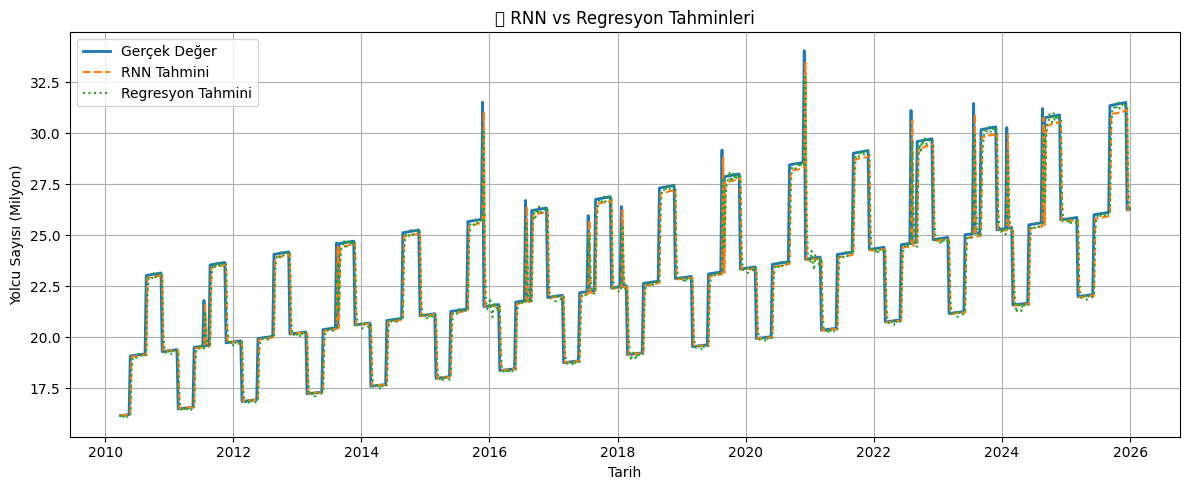

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Gerçek Değer', linewidth=2)
plt.plot(df.index[-len(rnn_preds_inv):], rnn_preds_inv, label='RNN Tahmini', linestyle='--')
plt.plot(df.index[-len(lr_preds_inv):], lr_preds_inv, label='Regresyon Tahmini', linestyle=':')
plt.title("📊 RNN vs Regresyon Tahminleri")
plt.xlabel("Tarih")
plt.ylabel("Yolcu Sayısı (Milyon)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


###  RNN and Linear Regression Comparison

In this study, two different time series forecasting methods were applied using weekly bus passenger number data: Recurrent Neural Network (RNN) and Linear Regression. Both models tried to forecast the next week using the past 12 weeks of data.

According to the evaluation made on the test data, the RNN model gave a more successful result with a mean absolute error (MAE) of 0.542 million passengers. The Linear Regression model produced a slightly higher error than the RNN with a MAE of 0.588 million.

The results show that although the dataset has a relatively linear structure, the RNN can learn complex patterns over time better and therefore make more accurate predictions.